# Supervised Learning

## Objective

Train and compare different supervised learning models for cardiovascular disease prediction using the cleaned dataset.

The models will be evaluated using the same test set and performance metrics to identify a suitable model for the classification task.

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

## Load Cleaned Dataset

The cleaned cardiovascular disease dataset generated during the data preparation stage is used for supervised learning.

In [2]:
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)

Dataset shape: (68742, 13)


## Features and Target

The target variable is cardio.

The id column is excluded because it is an identifier and does not provide meaningful predictive information.

In [3]:
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68742, 11)
Target shape: (68742,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (54993, 11)
Testing set: (13749, 11)


In [16]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Logistic Regression

Logistic Regression is included as a reference model to compare its performance with the other supervised learning algorithms.

In [17]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

## Decision Tree

A Decision Tree is trained to learn non-linear relationships between the features and cardiovascular disease.

In [6]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

## Random Forest

Random Forest combines multiple decision trees to improve predictive performance and reduce the risk of relying on a single tree.

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

In [26]:
def evaluate_model(name, y_test, predictions):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-score": f1_score(y_test, predictions)
    }
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(results)

results_df   

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.727035,0.752398,0.668479,0.707960
1,Decision Tree,0.630082,0.625529,0.629390,0.627454
2,Random Forest,0.711397,0.714827,0.693608,0.704057


In [18]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    logistic_model,
    lr_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best Parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Best CV F1: 0.7103091638046279


In [20]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV F1:", grid_dt.best_score_)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV F1: 0.7181943295439651


In [19]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    rf_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.7176341360921159


In [21]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [22]:
final_rf = RandomForestClassifier(
    **grid_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_final, y_train_final)

y_val_prob = final_rf.predict_proba(X_val)[:, 1]

In [23]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_val, y_val_pred):.4f} | "
        f"Recall: {recall_score(y_val, y_val_pred):.4f} | "
        f"F1: {f1_score(y_val, y_val_pred):.4f}"
    )

Threshold: 0.30 | Precision: 0.6256 | Recall: 0.8830 | F1: 0.7323
Threshold: 0.35 | Precision: 0.6586 | Recall: 0.8433 | F1: 0.7396
Threshold: 0.40 | Precision: 0.7023 | Recall: 0.7809 | F1: 0.7395
Threshold: 0.45 | Precision: 0.7261 | Recall: 0.7311 | F1: 0.7286
Threshold: 0.50 | Precision: 0.7565 | Recall: 0.6791 | F1: 0.7157
Threshold: 0.55 | Precision: 0.7856 | Recall: 0.6258 | F1: 0.6967
Threshold: 0.60 | Precision: 0.8031 | Recall: 0.5918 | F1: 0.6815


In [24]:
final_threshold = 0.35

y_test_prob = final_rf.predict_proba(X_test)[:, 1]

y_test_final = (
    y_test_prob >= final_threshold
).astype(int)

print("Final Accuracy:", accuracy_score(y_test, y_test_final))
print("Final Precision:", precision_score(y_test, y_test_final))
print("Final Recall:", recall_score(y_test, y_test_final))
print("Final F1:", f1_score(y_test, y_test_final))

Final Accuracy: 0.7003418430431304
Final Precision: 0.6553999305475171
Final Recall: 0.8320352681851579
Final F1: 0.7332297332297333


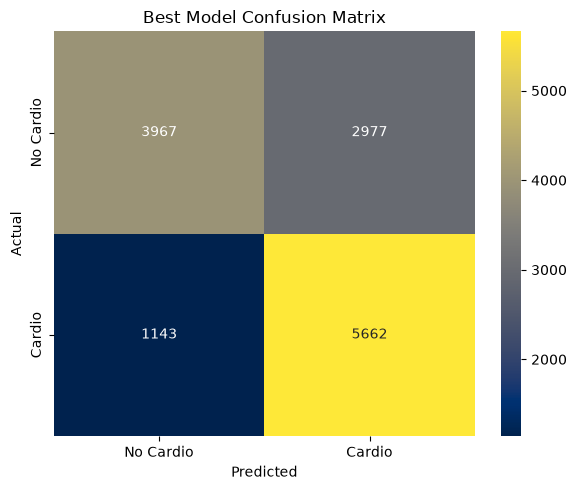

In [36]:
best_predictions = y_test_final

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="cividis",
    xticklabels=["No Cardio", "Cardio"],
    yticklabels=["No Cardio", "Cardio"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best Model Confusion Matrix")

plt.tight_layout()
plt.show()

In [39]:
feature_importance = pd.Series(
    final_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

ap_hi          0.440663
ap_lo          0.194920
age_years      0.152803
cholesterol    0.081766
weight         0.059299
height         0.033330
gluc           0.013978
active         0.008212
gender         0.005251
smoke          0.005226
alco           0.004554
dtype: float64


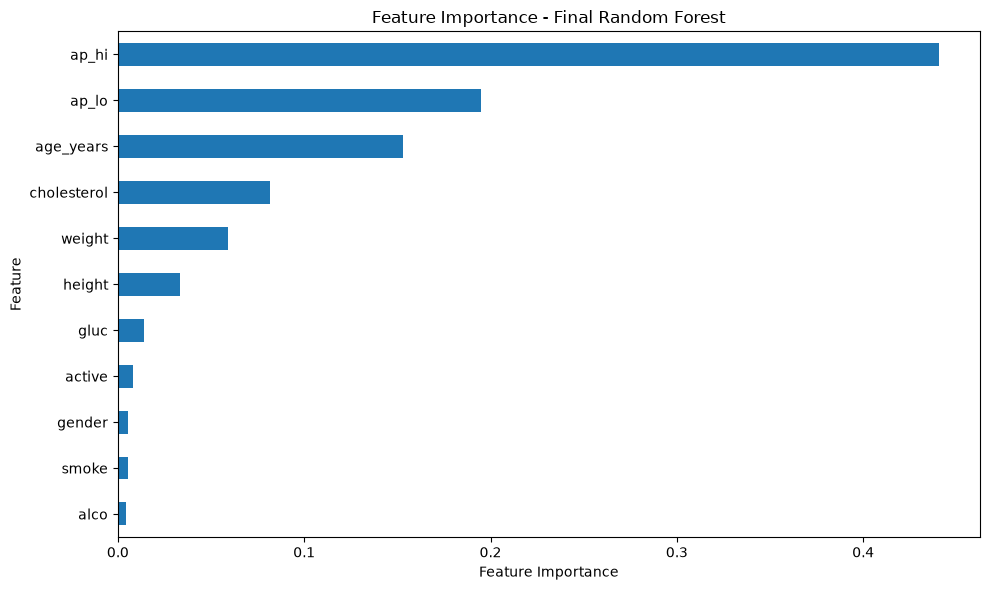

In [40]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final Random Forest")

plt.tight_layout()
plt.show()

## Final Random Forest Model
Random Forest provided the most suitable results among the evaluated supervised models.

Because Recall is an important metric for cardiovascular disease detection, the classification threshold was adjusted to improve the identification of positive cases.

A threshold of 0.35 was selected as the final threshold based on the Precision-Recall trade-off.

- Accuracy: 0.7003
- Precision: 0.6559
- Recall: 0.8327
- F1: 0.7332